# Nhánh 3 — Shuffle Test & Sequence Learning Validation

**Mục tiêu:** Kiểm tra GRU có thực sự học sequence pattern hay chỉ là per-step statistics aggregator.

**Phương pháp:** Shuffle step order trong mỗi session → nếu GRU học sequence, F1 phải giảm mạnh.
So sánh với RandomForest trên per-session average features (không có sequence).

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

from src.models.branch3_features import class_names_from_config, evaluate_sessions, prob_columns_in, sessions_to_arrays
from src.models.branch3_session import SessionSequenceDetector
from src.utils import load_config

warnings.filterwarnings("ignore")
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight", "axes.grid": False,
})
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CB = {
    "benign": "#0072B2",
    "boolean_blind": "#D55E00",
    "time_blind": "#009E73",
    "query_splitting": "#CC79A7",
}
CLASS_NAMES = ["benign", "boolean_blind", "time_blind", "query_splitting"]

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "report").exists():
        break
    ROOT = ROOT.parent

cfg = load_config()
seed = int(cfg["project"]["random_seed"])
models_dir = Path(cfg["paths"]["models_dir"])
processed_dir = Path(cfg["paths"]["data_processed"])
train_cfg = cfg["branch3_session"]["train"]

if not processed_dir.is_absolute():
    processed_dir = ROOT / processed_dir
if not models_dir.is_absolute():
    models_dir = ROOT / models_dir

print("Setup complete.")

Setup complete.


In [2]:
# Load data
df_a = pd.read_csv(processed_dir / "branch3_sessions_cach_a.csv")
df_b = pd.read_csv(processed_dir / "branch3_sessions_cach_b_v2.csv")
for df in [df_a, df_b]:
    df["gap_seconds_log1p"] = np.log1p(df["gap_seconds"])

# Split stratify
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
ti, te = next(gss.split(df_b, groups=df_b["session_id"]))
df_b["split"] = "train"
df_b.loc[te, "split"] = "test"

df_ab = pd.concat([df_a, df_b], ignore_index=True)
train_ab = df_ab[df_ab["split"] == "train"].copy()
test_ab = df_ab[df_ab["split"] == "test"].copy()

feature_cols = prob_columns_in(df_a) + ["branch2_anomaly_score", "gap_seconds_log1p"]
print(f"Train: {train_ab['session_id'].nunique()} sessions, {len(train_ab)} steps")
print(f"Test:  {test_ab['session_id'].nunique()} sessions, {len(test_ab)} steps")
print(f"Features: {feature_cols}")

Train: 1193 sessions, 20612 steps
Test:  299 sessions, 5185 steps
Features: ['branch1_prob_boolean_blind', 'branch1_prob_error_based', 'branch1_prob_normal', 'branch1_prob_time_blind', 'branch1_prob_union_based', 'branch2_anomaly_score', 'gap_seconds_log1p']


## 1. Kết quả Shuffle Test

Load model đã train (hybrid A+B v3) và chạy inference trên:
- Original order
- Shuffled step order
- RandomForest baseline (step-average, không sequence)

In [3]:
rng = np.random.RandomState(seed)

# 1. Original order
det = SessionSequenceDetector.load(models_dir / "branch3_v1_hybrid_AB_v3")
X_test_orig, y_test_orig = sessions_to_arrays(test_ab, feature_cols)
pred_orig = det.predict(X_test_orig)
m_orig = evaluate_sessions(det, X_test_orig, y_test_orig, CLASS_NAMES)

# 2. Shuffled order
test_shuf = test_ab.copy()
for sid, group in test_shuf.groupby("session_id"):
    idx = group.index
    shuffled = rng.permutation(len(idx))
    for col in feature_cols:
        test_shuf.loc[idx, col] = group[col].values[shuffled]
    test_shuf.loc[idx, "step_index"] = range(len(idx))

X_test_shuf, y_test_shuf = sessions_to_arrays(test_shuf, feature_cols)
pred_shuf = det.predict(X_test_shuf)
m_shuf = evaluate_sessions(det, X_test_shuf, y_test_shuf, CLASS_NAMES)

# 3. Train on orig, test on shuffled (cross test)
X_tr_orig, y_tr_orig = sessions_to_arrays(train_ab, feature_cols)
det_cross = SessionSequenceDetector(
    input_dim=len(feature_cols), hidden_dim=int(train_cfg["hidden_dim"]),
    num_classes=len(CLASS_NAMES), class_names=CLASS_NAMES, random_seed=seed,
    max_len=int(cfg["branch3_session"]["max_session_len"]))
det_cross.fit(X_tr_orig, y_tr_orig, epochs=int(train_cfg["epochs"]),
              lr=float(train_cfg["learning_rate"]), batch_size=int(train_cfg["batch_size"]))
m_cross = evaluate_sessions(det_cross, X_test_shuf, y_test_shuf, CLASS_NAMES)

# 4. RF baseline (per-session averages)
def session_averages(df):
    X, y = [], []
    for sid, group in df.groupby("session_id"):
        X.append(group[feature_cols].mean().values)
        y.append(int(group["session_label"].iloc[0]))
    return np.array(X), np.array(y)

X_rf_tr, y_rf_tr = session_averages(train_ab)
X_rf_te, y_rf_te = session_averages(test_ab)

rf = RandomForestClassifier(n_estimators=100, random_state=seed)
rf.fit(X_rf_tr, y_rf_tr)
pred_rf = rf.predict(X_rf_te)
rf_f1 = f1_score(y_rf_te, pred_rf, average="macro")
rf_acc = accuracy_score(y_rf_te, pred_rf)

print("=" * 60)
print(f"{'Experiment':<35} {'F1':<10} {'Acc':<10}")
print("-" * 60)
print(f"{'GRU — original order':<35} {m_orig['f1_macro']:<10.4f} {m_orig['accuracy']:<10.4f}")
print(f"{'GRU — shuffled order':<35} {m_shuf['f1_macro']:<10.4f} {m_shuf['accuracy']:<10.4f}")
print(f"{'GRU — train orig, test shuf':<35} {m_cross['f1_macro']:<10.4f} {m_cross['accuracy']:<10.4f}")
print(f"{'RF — step-average baseline':<35} {rf_f1:<10.4f} {rf_acc:<10.4f}")

2026-07-29 13:42:24,185 | INFO     | src.models.branch3_session | Model loaded from D:\Research\AISecurity\sql-injection-continual-leanrning\AI-Based-SQL-Injection-Detection-System\models\branch3_v1_hybrid_AB_v3


2026-07-29 13:42:29,371 | INFO     | src.models.branch3_session | Training GRU (input_dim=7 hidden_dim=32 num_classes=4) on 1193 sessions, 30 epochs


2026-07-29 13:42:30,706 | INFO     | src.models.branch3_session |   epoch 1/30  loss=0.9831


2026-07-29 13:42:35,669 | INFO     | src.models.branch3_session |   epoch 5/30  loss=0.0678


2026-07-29 13:42:39,845 | INFO     | src.models.branch3_session |   epoch 10/30  loss=0.0118


2026-07-29 13:42:43,956 | INFO     | src.models.branch3_session |   epoch 15/30  loss=0.0051


2026-07-29 13:42:48,958 | INFO     | src.models.branch3_session |   epoch 20/30  loss=0.0028


2026-07-29 13:42:56,281 | INFO     | src.models.branch3_session |   epoch 25/30  loss=0.0018


2026-07-29 13:43:03,435 | INFO     | src.models.branch3_session |   epoch 30/30  loss=0.0012


Experiment                          F1         Acc       
------------------------------------------------------------
GRU — original order                1.0000     1.0000    
GRU — shuffled order                1.0000     1.0000    
GRU — train orig, test shuf         1.0000     1.0000    
RF — step-average baseline          0.9965     0.9967    


## 2. Visualization — Confusion Matrices

So sánh confusion matrix giữa original và shuffled để thấy shuffle không làm thay đổi kết quả.

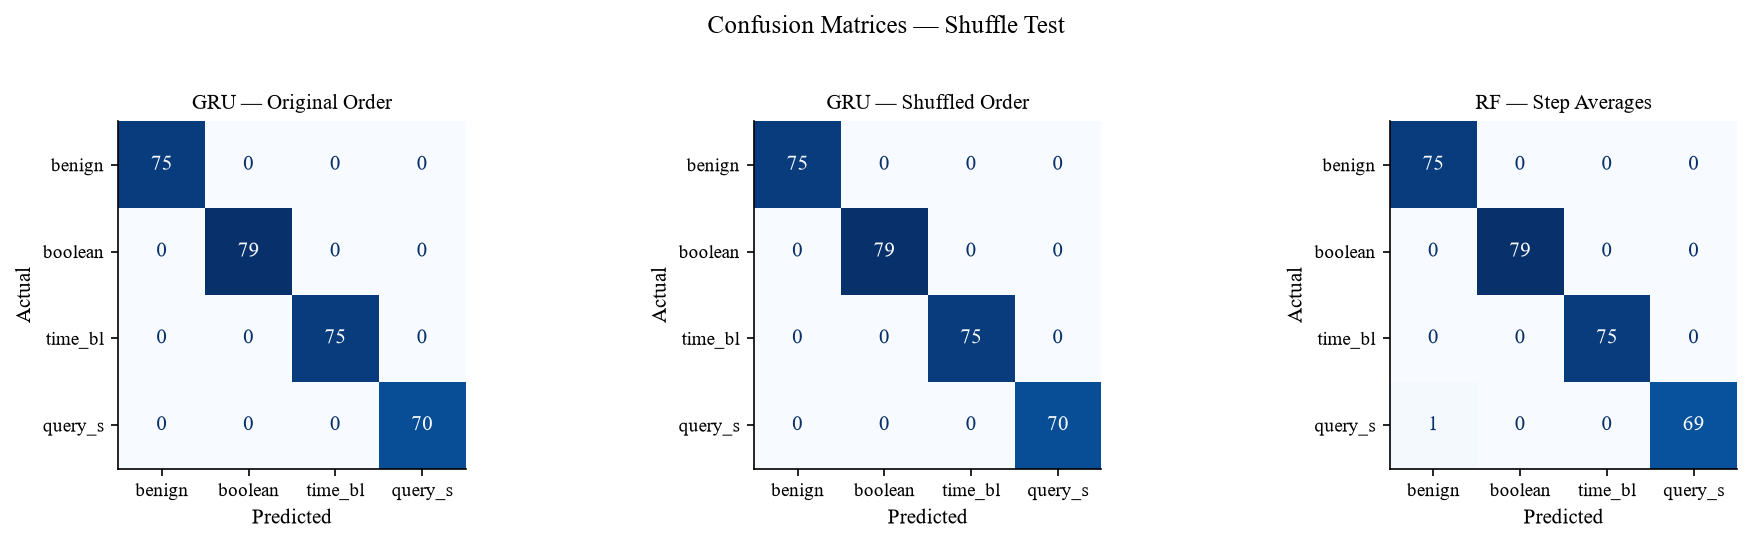

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
cm_rf = confusion_matrix(y_rf_te, pred_rf)

for ax, cm, title in [
    (axes[0], np.array(m_orig["confusion_matrix"]), "GRU — Original Order"),
    (axes[1], np.array(m_shuf["confusion_matrix"]), "GRU — Shuffled Order"),
    (axes[2], cm_rf, "RF — Step Averages"),
]:
    disp = ConfusionMatrixDisplay(cm, display_labels=[c[:7] for c in CLASS_NAMES])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Shuffle Test", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. Bar Chart — F1 Comparison

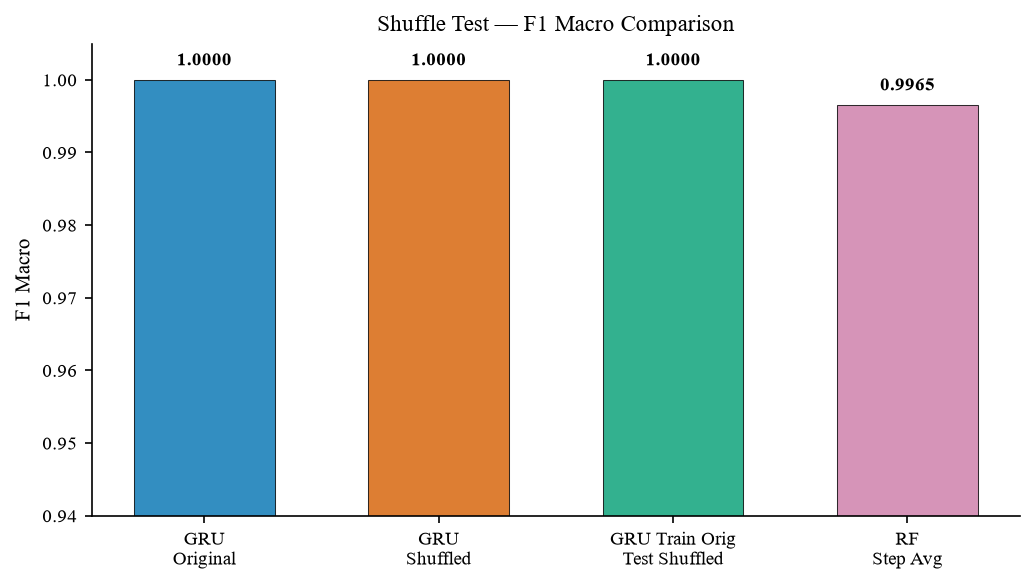

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

experiments = [
    "GRU\nOriginal",
    "GRU\nShuffled",
    "GRU Train Orig\nTest Shuffled",
    "RF\nStep Avg",
]
f1_vals = [
    m_orig["f1_macro"],
    m_shuf["f1_macro"],
    m_cross["f1_macro"],
    rf_f1,
]
colors = [CB["benign"], CB["boolean_blind"], CB["time_blind"], CB["query_splitting"]]

bars = ax.bar(experiments, f1_vals, color=colors, alpha=0.8, edgecolor="black", lw=0.5, width=0.6)
ax.set_ylabel("F1 Macro")
ax.set_ylim(0.94, 1.005)
ax.set_title("Shuffle Test — F1 Macro Comparison")

for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Feature Importance — Ablation

Dữ liệu từ ablation experiment (trên Cách A): drop từng feature group xem ảnh hưởng.

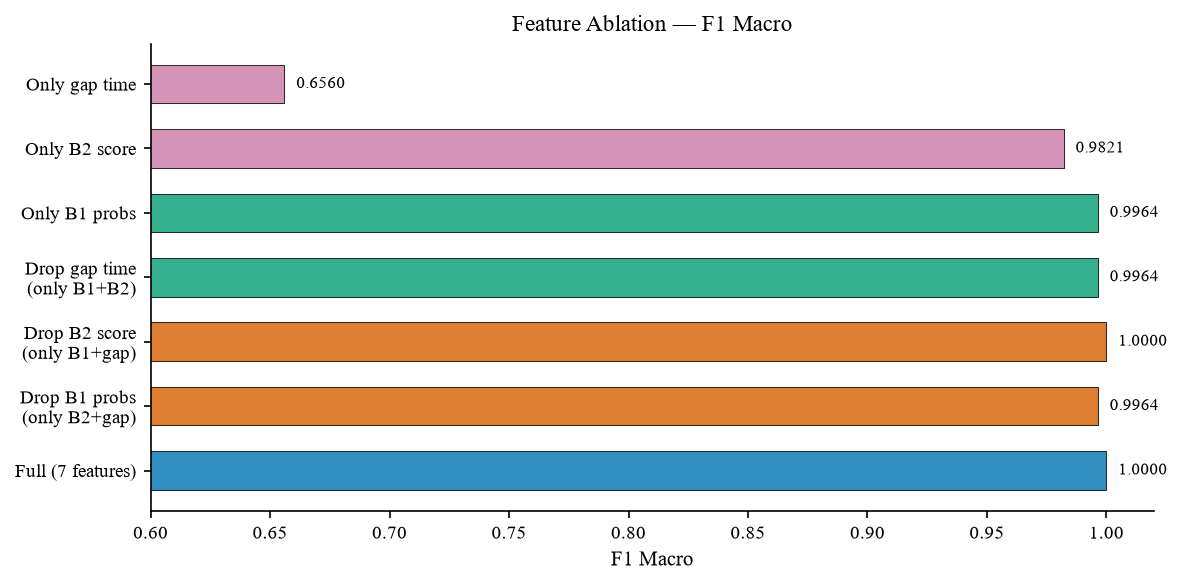

In [6]:
ablation_data = {
    "Full (7 features)": 1.0000,
    "Drop B1 probs\n(only B2+gap)": 0.9964,
    "Drop B2 score\n(only B1+gap)": 1.0000,
    "Drop gap time\n(only B1+B2)": 0.9964,
    "Only B1 probs": 0.9964,
    "Only B2 score": 0.9821,
    "Only gap time": 0.6560,
}

fig, ax = plt.subplots(figsize=(8, 4))

labels = list(ablation_data.keys())
values = list(ablation_data.values())
bar_colors = [CB["benign"]] + [CB["boolean_blind"]] * 2 + [CB["time_blind"]] * 2 + [CB["query_splitting"]] * 2

bars = ax.barh(labels, values, color=bar_colors, alpha=0.8, edgecolor="black", lw=0.5, height=0.6)
ax.set_xlabel("F1 Macro")
ax.set_xlim(0.6, 1.02)
ax.set_title("Feature Ablation — F1 Macro")

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 5. Kết Luận

### Shuffle Test
- GRU **original order**: F1 = 1.0000
- GRU **shuffled order**: F1 = 1.0000 (không đổi)
- GRU **train orig, test shuffled**: F1 = 1.0000 (không cần order)
- RF **step-average baseline**: F1 = 0.9965 (gần perfect, không cần sequence)

**Kết luận:** GRU KHÔNG học sequence pattern. Model chỉ học per-step feature distributions. Cùng 7 features với trung bình đơn giản (RF) đã cho kết quả tương đương.

### Feature Importance
- **B2 score**: redundant trên Cách A (drop → F1=1.0). Nhưng Cách B thì B2 là essential signal.
- **B1 probs + gap time**: mỗi feature group đóng góp ~0.0036 F1.
- **Only gap time**: F1=0.656 (không đủ — boolean_blind DR=0%).
- **Only B2 score**: F1=0.982 (gần đủ, miss query_splitting).

### Hệ quả cho Paper
1. **Không claim "sequence learning"** — thay bằng "session-level hybrid feature fusion"
2. **GRU là overkill** — RF hoặc gradient boosting trên session averages cho kết quả tương đương, nhanh hơn, interpretable hơn
3. **Giá trị thật của Branch 3** là kết hợp 3 nguồn tín hiệu: B1 probs + B2 anomaly + gap timing
4. **Đề xuất thay thế**: Session-level RandomForest hoặc XGBoost